In [12]:
#%config InlineBackend.figure_formats=['svg']
# Generic import 
import numpy as np
from os import listdir
import matplotlib.pyplot as plt
# Train a model
from AutoencoderAPI.recurrentTriplet import recurrentTriplet
from AutoencoderAPI.utils.plot import load_run_results, load_sweep_results
from AutoencoderAPI.loadAutoencoder import plot_weigths
# Define clustering
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture

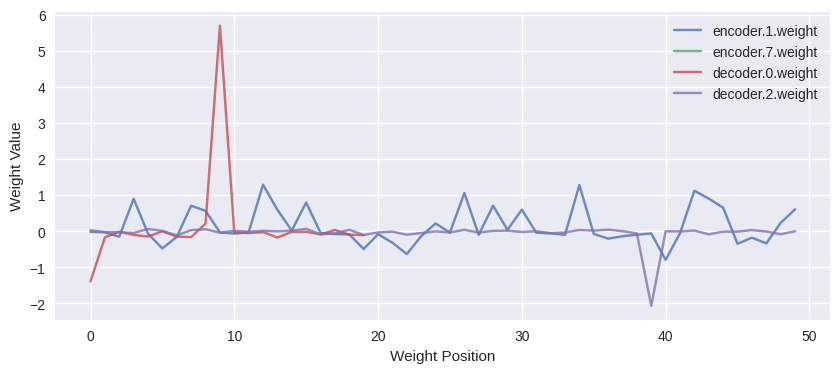

In [13]:
plot_weigths('AutoencoderLog/grid-search-SPSPD param (dropout with zero photon)/run 06/fold 0')

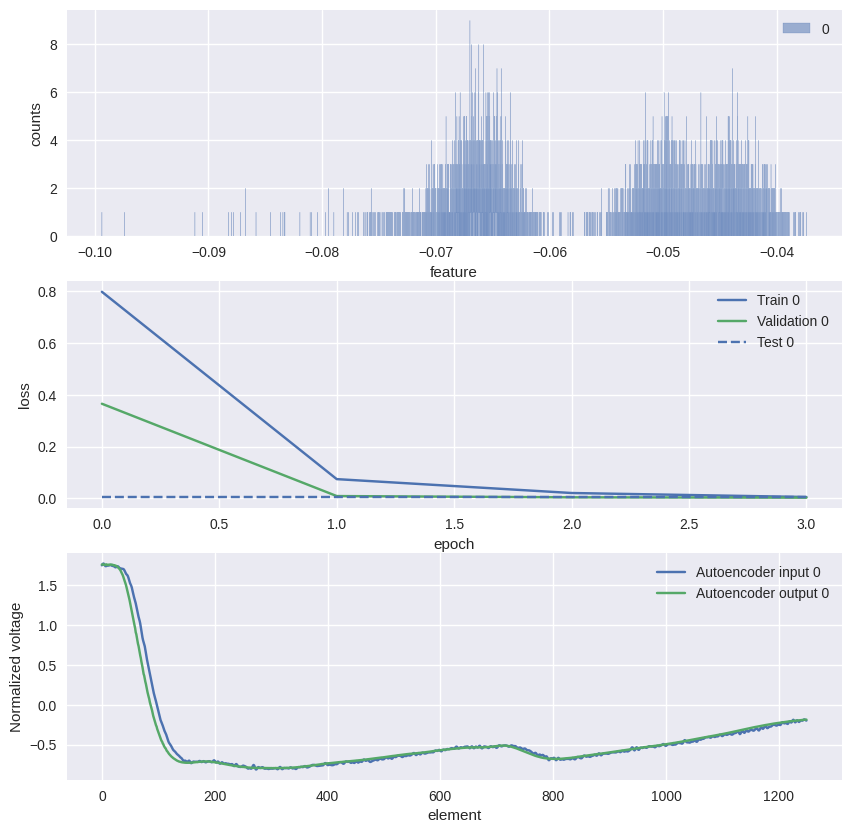

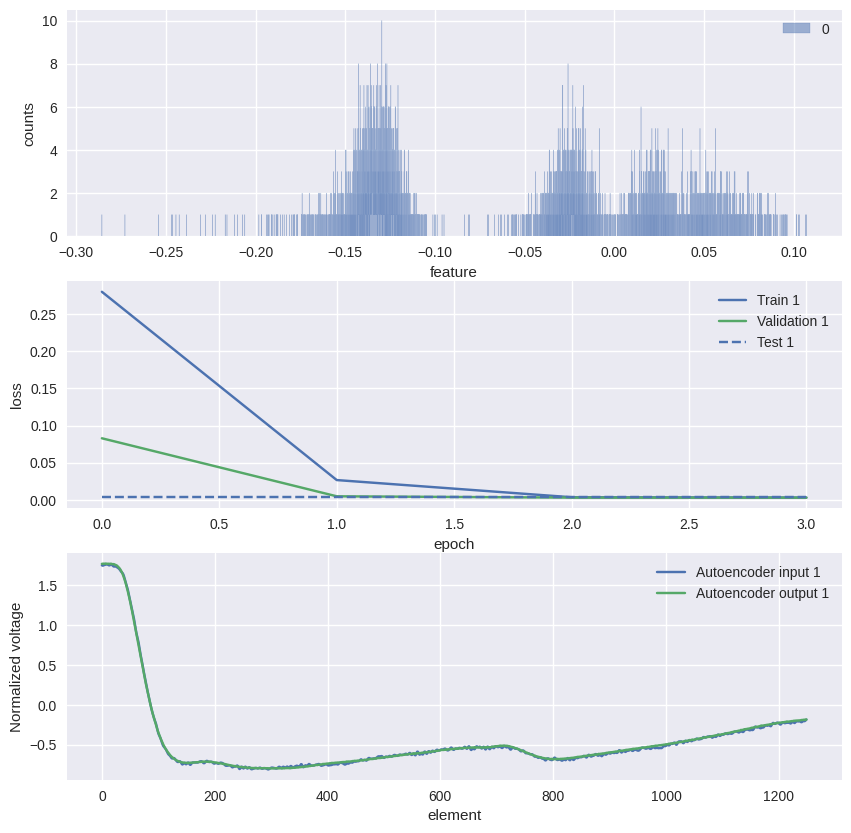

In [21]:
load_run_results('AutoencoderLog/run-2024-01-09-19-20')

min :  0.10589898377777882
learning_rate :  0.001
epochs :  3
[0.4633161660758589, 0.13456007966596154, 0.18067285607196681, 0.14408887031025078, 0.14560791167442222, 0.4566220109408954, 1.9468409047296271, 0.10589898377777882, 0.11146664217403013, 0.14610442208131752, 0.127643261198909, 0.3738550561497803, 0.14908431449924187, 0.1479719726859982, 0.11843494815794128, 0.1680750173842036, 0.17419243586840677, 0.33915707626728686, 0.7559534712912515, 0.18931770688556715, 0.0, 0.0, 0.0, 0.0]


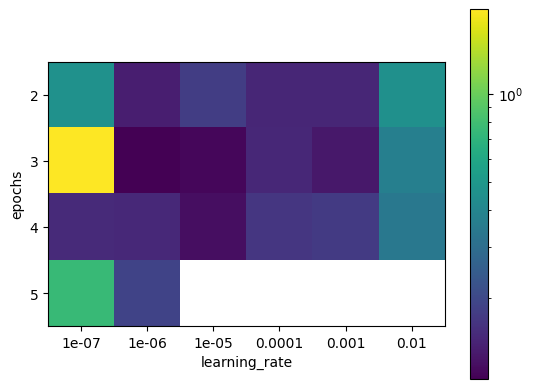

In [15]:
load_sweep_results("grid-search-SPSPD param (dropout with zero photon)", ["learning_rate", "epochs"])

In [16]:
from AutoencoderAPI.utils.files import load_mean_std
import numpy as np
from os import listdir

signal_size = 30_000
path_test = 'Datasets/SNSPD/Paderborn/data/'
path_train = 'Datasets/SNSPD/Paderborn/data1/'
path_model = 'run-2024-01-06-12-21/fold 0'
mean, std = load_mean_std(path_model)
print(mean, std)

X_test = np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size)[::4, 3250:4500] for fileName in listdir(path_test)[::2]])
#X_train = np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::4, 3250:4500] for fileName in listdir(path_train)[::2]])

X_test = (X_test - mean)/std
#X_train = (X_train - mean)/std

X_test = X_test[np.min(X_test, axis=1) < -0.5]
X_test = X_test[np.max(X_test, axis=1) > 1.75]
X_test = X_test[np.argmax(X_test, axis=1) < 50]

-10153.858890977777 16902.639283052387


In [17]:
from AutoencoderAPI.encoderStack import encoderStack

es = encoderStack()
X, labels = es.stack(X_test, "AutoencoderLog/testStack")

TypeError: masked_select(): argument 'input' (position 1) must be Tensor, not numpy.ndarray